# Выделение режимов бурения (энергоёмкость породы) через кластеризацию

**Задача:** выделить скрытый параметр — энергоёмкость породы (cluster), затем для каждого режима обучить модели, предсказывающие `speed` и `rotation` по `pressure_axis`, `pressure_rotation`.

**Ключевое решение по метрике:**
- **Основная метрика — глобальный OOF RMSE** (в физических единицах, не зависит от разложения дисперсии)
- **Дополнительно — глобальный OOF R²** (считается по всем предсказаниям, а не усредняется по кластерам)
- **Диагностика — per-cluster RMSE** (выявляет неоднородные режимы)

**Почему не R² как основная метрика:** R² растёт с увеличением k просто за счёт того, что кластеры становятся теснее. RMSE покажет реальное "колено" — после которого дробление на новые режимы уже не улучшает предсказание.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GroupKFold

sns.set_style('whitegrid')
RANDOM_STATE = 21
N_SPLITS = 5

In [2]:
df = pd.read_feather('../datasets/united.feather')
print(f'Shape: {df.shape}, wells: {df["well_id"].nunique()}')
df[['pressure_axis', 'pressure_rotation', 'speed', 'rotation']].describe()

Shape: (415049, 6), wells: 1706


,pressure_axis,pressure_rotation,speed,rotation
count,415049.000000,415049.000000,415049.000000,415049.000000
mean,17473.667273,14134.146325,0.013116,103.945315
std,4682.982816,3243.523440,0.006615,13.370361
min,317.000000,784.000000,0.001002,50.010000
25%,15739.000000,12040.000000,0.006060,101.382000
50%,18861.000000,14637.000000,0.012120,103.158000
75%,20808.000000,16387.000000,0.018180,104.940000
max,24872.000000,26318.000000,0.038957,139.578000


## 1. Подготовка

In [3]:
CLUSTER_FEATURES = ['pressure_axis', 'pressure_rotation', 'speed', 'rotation']
REGRESSION_FEATURES = ['pressure_axis', 'pressure_rotation']
TARGETS = ['speed', 'rotation']

X_raw = df[CLUSTER_FEATURES].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

groups = df['well_id'].values
gkf = GroupKFold(n_splits=N_SPLITS)



## 2. Evaluation framework

Для каждой конфигурации кластеризации:
1. Обучаем **отдельный LightGBM на каждый кластер** (фичи: `p_ax`, `p_rot`)
2. Собираем OOF-предсказания через GroupKFold (группы — скважины)
3. Считаем **глобальный RMSE** и **глобальный R²** по всему датасету
4. Считаем **per-cluster RMSE** для диагностики

In [4]:
def evaluate_clustering(cluster_labels):
    """
    Per-cluster LightGBM, OOF evaluation.
    Returns dict with global RMSE/R² and per-cluster RMSE.
    """
    unique_clusters = np.unique(cluster_labels)
    oof = {t: np.full(len(df), np.nan) for t in TARGETS}
    
    per_cluster_stats = []
    
    for cid in unique_clusters:
        mask = cluster_labels == cid
        n_obs = mask.sum()
        if n_obs < 50:
            continue
        
        feat = df.loc[mask, REGRESSION_FEATURES]
        grp = df.loc[mask, 'well_id'].values
        n_unique_groups = len(np.unique(grp))
        n_sp = min(N_SPLITS, n_unique_groups)
        if n_sp < 2:
            continue
        
        cluster_rmse = {}
        for target in TARGETS:
            y = df.loc[mask, target].values
            fold_preds = np.full(len(y), np.nan)
            for tr, te in GroupKFold(n_splits=n_sp).split(feat, y, grp):
                m = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
                m.fit(feat.iloc[tr], y[tr])
                fold_preds[te] = m.predict(feat.iloc[te])
            oof[target][mask] = fold_preds
            valid = ~np.isnan(fold_preds)
            cluster_rmse[target] = np.sqrt(mean_squared_error(y[valid], fold_preds[valid]))
        
        per_cluster_stats.append({
            'cluster': cid, 'n_obs': n_obs,
            'rmse_speed': cluster_rmse['speed'],
            'rmse_rotation': cluster_rmse['rotation'],
        })
    
    # Global metrics
    result = {}
    for target in TARGETS:
        valid = ~np.isnan(oof[target])
        coverage = valid.sum() / len(df)
        y_true = df[target].values[valid]
        y_pred = oof[target][valid]
        result[f'rmse_{target}'] = np.sqrt(mean_squared_error(y_true, y_pred))
        result[f'r2_{target}'] = r2_score(y_true, y_pred)
    
    result['coverage'] = coverage
    result['per_cluster'] = pd.DataFrame(per_cluster_stats)
    result['oof'] = oof
    return result

## 3. Grid search: кластеризация × число кластеров

In [5]:
k_range = range(3, 11)
rows = []
all_labels = {}  # (method, k) -> labels
all_evals = {}   # (method, k) -> eval result

# ── KMeans ──
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_scaled)
    all_labels[('KMeans', k)] = labels
    ev = evaluate_clustering(labels)
    all_evals[('KMeans', k)] = ev
    rows.append({'method': 'KMeans', 'k': k, **{m: ev[m] for m in ['rmse_speed','rmse_rotation','r2_speed','r2_rotation','coverage']}})
    print(f"KMeans k={k}: RMSE_speed={ev['rmse_speed']:.6f}, RMSE_rot={ev['rmse_rotation']:.4f}, R²_speed={ev['r2_speed']:.4f}, R²_rot={ev['r2_rotation']:.4f}")

# ── GMM ──
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    labels = gmm.fit_predict(X_scaled)
    all_labels[('GMM', k)] = labels
    ev = evaluate_clustering(labels)
    all_evals[('GMM', k)] = ev
    rows.append({'method': 'GMM', 'k': k, **{m: ev[m] for m in ['rmse_speed','rmse_rotation','r2_speed','r2_rotation','coverage']}})
    print(f"GMM k={k}: RMSE_speed={ev['rmse_speed']:.6f}, RMSE_rot={ev['rmse_rotation']:.4f}, R²_speed={ev['r2_speed']:.4f}, R²_rot={ev['r2_rotation']:.4f}")

KMeans k=3: RMSE_speed=0.004446, RMSE_rot=12.2894, R²_speed=0.5483, R²_rot=0.1552
KMeans k=4: RMSE_speed=0.004480, RMSE_rot=7.5086, R²_speed=0.5414, R²_rot=0.6846
KMeans k=5: RMSE_speed=0.004375, RMSE_rot=7.2988, R²_speed=0.5626, R²_rot=0.7020
KMeans k=6: RMSE_speed=0.004321, RMSE_rot=5.7014, R²_speed=0.5733, R²_rot=0.8182
KMeans k=7: RMSE_speed=0.003857, RMSE_rot=5.8133, R²_speed=0.6600, R²_rot=0.8110
KMeans k=8: RMSE_speed=0.003841, RMSE_rot=5.1462, R²_speed=0.6628, R²_rot=0.8519
KMeans k=9: RMSE_speed=0.003831, RMSE_rot=4.0280, R²_speed=0.6647, R²_rot=0.9092
KMeans k=10: RMSE_speed=0.003785, RMSE_rot=4.1248, R²_speed=0.6726, R²_rot=0.9048
GMM k=3: RMSE_speed=0.006008, RMSE_rot=9.6349, R²_speed=0.1752, R²_rot=0.4807
GMM k=4: RMSE_speed=0.005712, RMSE_rot=4.5123, R²_speed=0.2545, R²_rot=0.8861
GMM k=5: RMSE_speed=0.005690, RMSE_rot=4.5453, R²_speed=0.2600, R²_rot=0.8844
GMM k=6: RMSE_speed=0.005764, RMSE_rot=4.4881, R²_speed=0.2409, R²_rot=0.8873
GMM k=7: RMSE_speed=0.005272, RMSE_rot

In [6]:
results_df = pd.DataFrame(rows)
results_df.sort_values('rmse_speed')

,method,k,rmse_speed,rmse_rotation,r2_speed,r2_rotation,coverage
7,KMeans,10,0.003785,4.124799,0.672633,0.904826,1.0
6,KMeans,9,0.003831,4.028043,0.664670,0.909238,1.0
5,KMeans,8,0.003841,5.146232,0.662845,0.851853,1.0
4,KMeans,7,0.003857,5.813266,0.659993,0.810959,1.0
3,KMeans,6,0.004321,5.701367,0.573267,0.818167,1.0
2,KMeans,5,0.004375,7.298847,0.562570,0.701995,1.0
0,KMeans,3,0.004446,12.289377,0.548273,0.155160,1.0
1,KMeans,4,0.004480,7.508610,0.541410,0.684620,1.0
15,GMM,10,0.005136,4.138413,0.397272,0.904196,1.0
14,GMM,9,0.005161,4.528596,0.391336,0.885279,1.0


## 4. Визуализация: поиск "колена" по RMSE

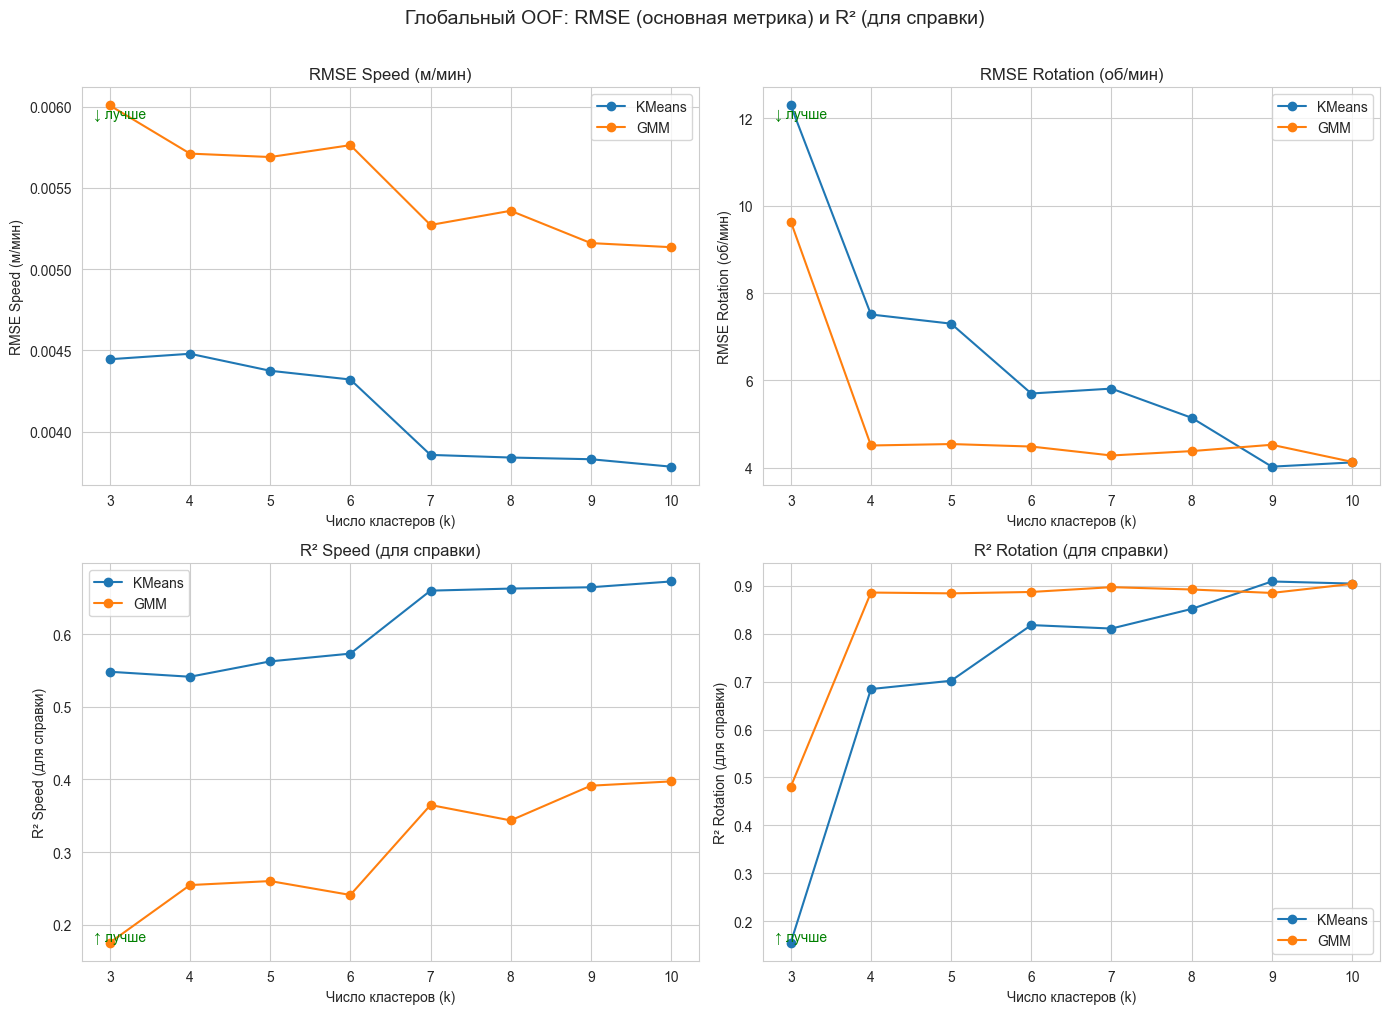

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_plot = [
    ('rmse_speed', 'RMSE Speed (м/мин)', True),
    ('rmse_rotation', 'RMSE Rotation (об/мин)', True),
    ('r2_speed', 'R² Speed (для справки)', False),
    ('r2_rotation', 'R² Rotation (для справки)', False),
]

for ax, (metric, title, lower_better) in zip(axes.flat, metrics_plot):
    for method in ['KMeans', 'GMM']:
        sub = results_df[results_df['method'] == method].sort_values('k')
        ax.plot(sub['k'], sub[metric], 'o-', label=method, markersize=6)
    ax.set_xlabel('Число кластеров (k)')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend()
    ax.set_xticks(list(k_range))
    if lower_better:
        ax.annotate('↓ лучше', xy=(0.02, 0.95), xycoords='axes fraction', fontsize=10, color='green', va='top')
    else:
        ax.annotate('↑ лучше', xy=(0.02, 0.05), xycoords='axes fraction', fontsize=10, color='green')

plt.suptitle('Глобальный OOF: RMSE (основная метрика) и R² (для справки)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Выбор оптимальной конфигурации

Ищем "колено" — точку, после которой RMSE снижается незначительно. Это реальное число режимов энергоёмкости.

In [8]:
# Суммарный нормированный RMSE (оба таргета равноважны)
results_df['rmse_speed_norm'] = results_df['rmse_speed'] / results_df['rmse_speed'].max()
results_df['rmse_rotation_norm'] = results_df['rmse_rotation'] / results_df['rmse_rotation'].max()
results_df['rmse_combined'] = results_df['rmse_speed_norm'] + results_df['rmse_rotation_norm']

# Для каждого метода: процент снижения RMSE при добавлении кластера
print('Относительное снижение combined RMSE при увеличении k на 1:\n')
for method in ['KMeans', 'GMM']:
    sub = results_df[results_df['method'] == method].sort_values('k')
    pct_change = sub['rmse_combined'].pct_change() * 100
    for k, pct in zip(sub['k'], pct_change):
        if not np.isnan(pct):
            print(f'  {method} k={k}: {pct:+.2f}%')
    print()

Относительное снижение combined RMSE при увеличении k на 1:

  KMeans k=4: -22.03%
  KMeans k=5: -2.54%
  KMeans k=6: -10.51%
  KMeans k=7: -5.76%
  KMeans k=8: -5.11%
  KMeans k=9: -8.76%
  KMeans k=10: +0.03%

  GMM k=4: -26.13%
  GMM k=5: -0.06%
  GMM k=6: +0.57%
  GMM k=7: -7.43%
  GMM k=8: +1.85%
  GMM k=9: -1.71%
  GMM k=10: -2.93%



In [9]:
# Выбираем лучшую конфигурацию по combined RMSE
best_row = results_df.loc[results_df['rmse_combined'].idxmin()]
BEST_METHOD = best_row['method']
BEST_K = int(best_row['k'])

print(f'Лучшая конфигурация по combined RMSE:')
print(f'  Метод: {BEST_METHOD}, k={BEST_K}')
print(f'  RMSE speed:    {best_row["rmse_speed"]:.6f}')
print(f'  RMSE rotation: {best_row["rmse_rotation"]:.4f}')
print(f'  R² speed:      {best_row["r2_speed"]:.4f}')
print(f'  R² rotation:   {best_row["r2_rotation"]:.4f}')

# Но также покажем "колено" — конфигурацию с хорошим компромиссом k / RMSE
# (пользователь выберет сам, глядя на графики)

Лучшая конфигурация по combined RMSE:
  Метод: KMeans, k=9
  RMSE speed:    0.003831
  RMSE rotation: 4.0280
  R² speed:      0.6647
  R² rotation:   0.9092


## 6. Диагностика per-cluster RMSE для лучшей конфигурации

In [10]:
best_eval = all_evals[(BEST_METHOD, BEST_K)]
pc = best_eval['per_cluster'].sort_values('cluster')
print(f'{BEST_METHOD} k={BEST_K} — per-cluster RMSE:\n')
display(pc.style.background_gradient(subset=['rmse_speed', 'rmse_rotation'], cmap='RdYlGn_r'))

KMeans k=9 — per-cluster RMSE:



,cluster,n_obs,rmse_speed,rmse_rotation
0,0,104426,0.002748,2.522148
1,1,38364,0.003606,4.581344
2,2,88693,0.002951,2.923823
3,3,30015,0.005038,6.216360
4,4,15713,0.006235,10.218282
5,5,27418,0.005435,0.618155
6,6,17606,0.004178,7.935365
7,7,83775,0.003877,2.635641
8,8,9039,0.005585,0.738131


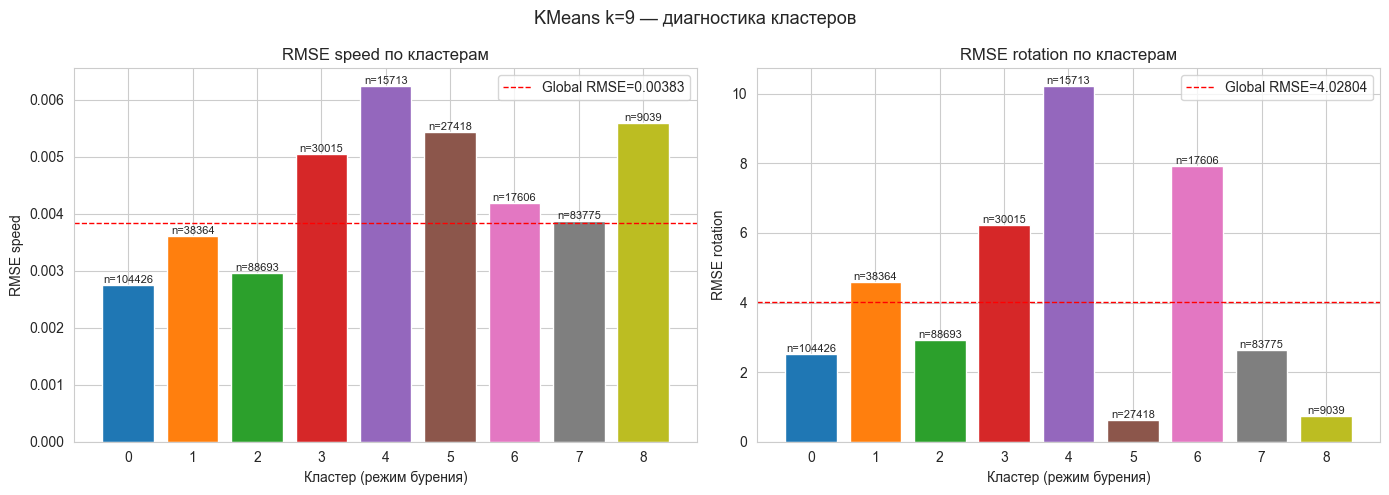


Если какой-то кластер имеет аномально большой RMSE — этот "режим" неоднороден и его стоит дробить.


In [11]:
# Per-cluster RMSE bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, TARGETS):
    col = f'rmse_{target}'
    bars = ax.bar(pc['cluster'].astype(str), pc[col], color=plt.cm.tab10.colors[:len(pc)])
    ax.set_xlabel('Кластер (режим бурения)')
    ax.set_ylabel(f'RMSE {target}')
    ax.set_title(f'RMSE {target} по кластерам')
    # Аннотируем размер кластера
    for bar, n in zip(bars, pc['n_obs']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'n={n}',
                ha='center', va='bottom', fontsize=8)
    # Глобальная линия
    ax.axhline(best_eval[f'rmse_{target}'], color='red', ls='--', lw=1, label=f'Global RMSE={best_eval[f"rmse_{target}"]:.5f}')
    ax.legend()
plt.suptitle(f'{BEST_METHOD} k={BEST_K} — диагностика кластеров', fontsize=13)
plt.tight_layout()
plt.show()

print('\nЕсли какой-то кластер имеет аномально большой RMSE — этот "режим" неоднороден и его стоит дробить.')

## 7. Predicted vs Actual — лучшая конфигурация

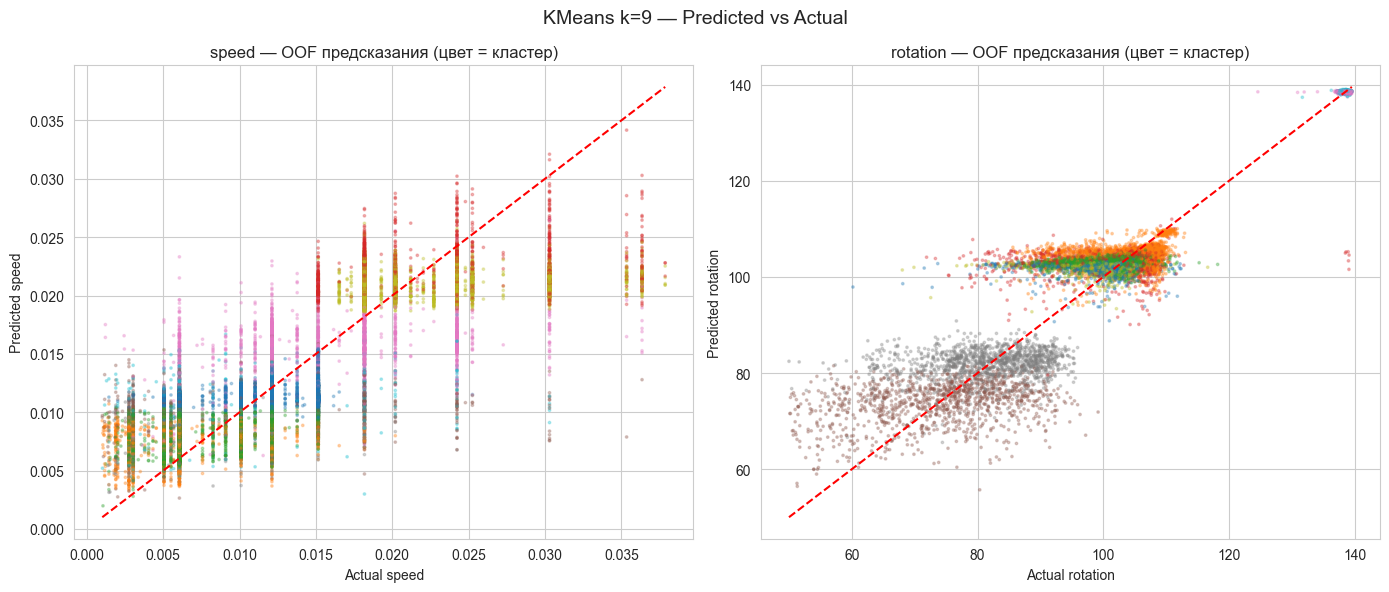

In [13]:
best_labels = all_labels[(BEST_METHOD, BEST_K)]
oof = best_eval['oof']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sample_n = min(30_000, len(df))
rng = np.random.default_rng()
s_idx = rng.choice(len(df), sample_n, replace=False)

for ax, target in zip(axes, TARGETS):
    valid = ~np.isnan(oof[target])
    # sample from valid
    valid_idx = np.where(valid)[0]
    plot_idx = rng.choice(valid_idx, min(sample_n, len(valid_idx)), replace=False)
    
    y_true = df[target].values[plot_idx]
    y_pred = oof[target][plot_idx]
    colors = best_labels[plot_idx]
    
    scatter = ax.scatter(y_true, y_pred, c=colors, cmap='tab10', s=3, alpha=0.3)
    mn, mx = y_true.min(), y_true.max()
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_xlabel(f'Actual {target}')
    ax.set_ylabel(f'Predicted {target}')
    ax.set_title(f'{target} — OOF предсказания (цвет = кластер)')

plt.suptitle(f'{BEST_METHOD} k={BEST_K} — Predicted vs Actual', fontsize=14)
plt.tight_layout()
plt.show()

## 8. Физическая интерпретация кластеров (режимы бурения)

In [14]:
df_viz = df[CLUSTER_FEATURES + ['well_id']].copy()
df_viz['cluster'] = best_labels

summary = df_viz.groupby('cluster')[CLUSTER_FEATURES].agg(['mean', 'std', 'count'])
summary.columns = ['_'.join(col) for col in summary.columns]
print(f'{BEST_METHOD} k={BEST_K} — средние параметры по кластерам (режимам):\n')
display(summary)

KMeans k=9 — средние параметры по кластерам (режимам):



,pressure_axis_mean,pressure_axis_std,pressure_axis_count,pressure_rotation_mean,pressure_rotation_std,pressure_rotation_count,speed_mean,speed_std,speed_count,rotation_mean,rotation_std,rotation_count
cluster,,,,,,,,,,,,
0,20717.320236,1593.741997,104426,16561.447264,1528.986570,104426,0.011369,0.002866,104426,102.238970,2.558606,104426
1,10429.050386,3467.509530,38364,9562.801559,1510.351719,38364,0.007818,0.003755,38364,104.894201,4.696218,38364
2,18279.328808,2002.435954,88693,13473.127237,1253.907644,88693,0.008296,0.003255,88693,102.898226,2.941116,88693
3,12549.147393,3586.810672,30015,11226.639614,1717.511727,30015,0.021844,0.005294,30015,103.426370,6.272672,30015
4,6163.055814,2571.379030,15713,7628.144212,1567.678724,15713,0.009881,0.006272,15713,73.759485,10.554523,15713
5,20087.674010,2006.310966,27418,15676.748413,1912.771087,27418,0.015119,0.006144,27418,138.473795,0.607870,27418
6,15839.399750,2288.945248,17606,11488.093775,1900.589167,17606,0.008960,0.004374,17606,81.618547,7.834938,17606
7,19850.440609,1860.343324,83775,16675.997613,1887.234251,83775,0.020816,0.003968,83775,102.254429,2.672867,83775
8,11234.308109,4459.613673,9039,9860.983295,2012.142896,9039,0.010391,0.005939,9039,138.526173,0.722204,9039


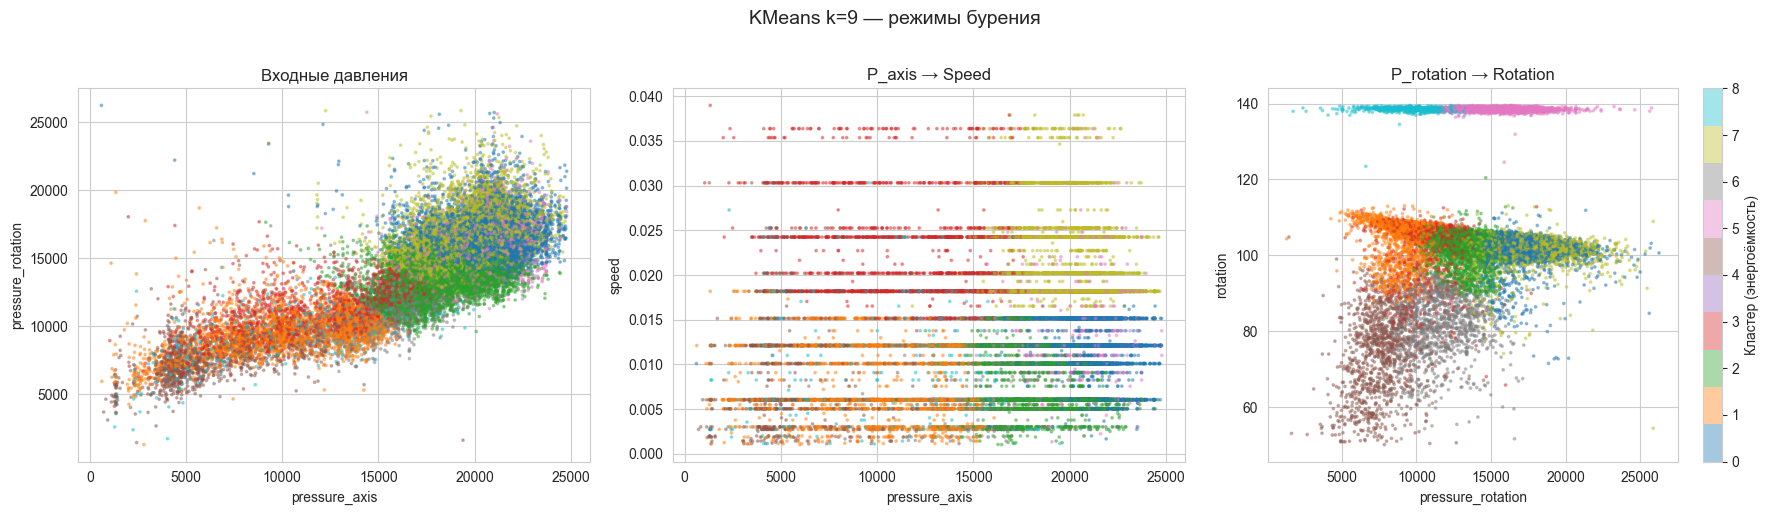

In [15]:
# Scatter: p_ax vs p_rot, раскрашенные кластером
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_sample = rng.choice(len(df_viz), min(30_000, len(df_viz)), replace=False)
ds = df_viz.iloc[plot_sample]

pairs = [
    ('pressure_axis', 'pressure_rotation', 'Входные давления'),
    ('pressure_axis', 'speed', 'P_axis → Speed'),
    ('pressure_rotation', 'rotation', 'P_rotation → Rotation'),
]

for ax, (x, y, title) in zip(axes, pairs):
    scatter = ax.scatter(ds[x], ds[y], c=ds['cluster'], cmap='tab10', s=3, alpha=0.4)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)

plt.colorbar(scatter, ax=axes[-1], label='Кластер (энергоёмкость)')
plt.suptitle(f'{BEST_METHOD} k={BEST_K} — режимы бурения', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

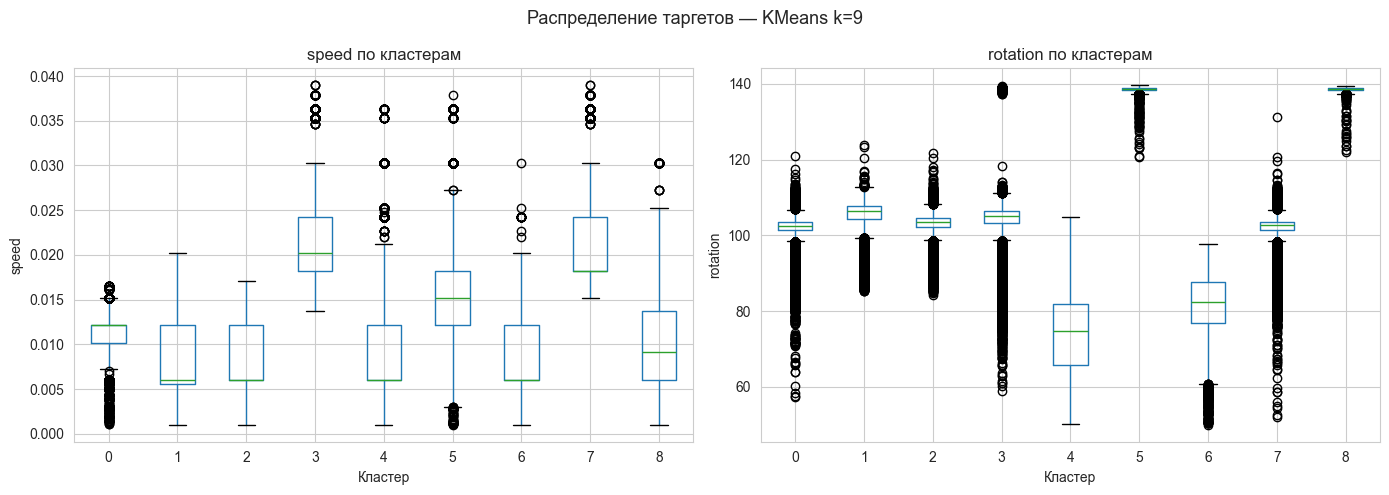

In [16]:
# Boxplots — распределения таргетов по кластерам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, TARGETS):
    df_viz.boxplot(column=target, by='cluster', ax=ax)
    ax.set_title(f'{target} по кластерам')
    ax.set_xlabel('Кластер')
    ax.set_ylabel(target)
plt.suptitle(f'Распределение таргетов — {BEST_METHOD} k={BEST_K}', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Два бейзлайна

Чтобы понять, откуда берётся качество предсказания, нужны два бейзлайна:

- **Бейзлайн 1 — среднее по кластеру:** предсказываем просто `mean(target)` внутри кластера, без регрессии. Показывает, сколько информации уже содержится в самом разбиении.
- **Бейзлайн 2 — единый LightGBM без кластеров:** одна модель на все данные. Показывает, нужна ли кластеризация вообще.

Если per-cluster LightGBM ≈ среднее по кластеру → давления внутри режима бесполезны.  
Если per-cluster LightGBM ≈ единая модель → кластеризация не помогает.

In [17]:
# ── Бейзлайн 1: среднее по кластеру (для каждой конфигурации) ──
# Считаем OOF cluster-mean через GroupKFold, чтобы было честно

baseline_mean_rows = []

for (method, k), labels in all_labels.items():
    oof_mean = {t: np.full(len(df), np.nan) for t in TARGETS}
    
    for cid in np.unique(labels):
        mask = labels == cid
        if mask.sum() < 50:
            continue
        grp = df.loc[mask, 'well_id'].values
        n_unique = len(np.unique(grp))
        n_sp = min(N_SPLITS, n_unique)
        if n_sp < 2:
            continue
        feat = df.loc[mask, REGRESSION_FEATURES]  # нужен только для split
        for target in TARGETS:
            y = df.loc[mask, target].values
            fold_preds = np.full(len(y), np.nan)
            for tr, te in GroupKFold(n_splits=n_sp).split(feat, y, grp):
                fold_preds[te] = y[tr].mean()  # просто среднее по train fold
            oof_mean[target][mask] = fold_preds
    
    row = {'method': method, 'k': k}
    for target in TARGETS:
        valid = ~np.isnan(oof_mean[target])
        row[f'rmse_{target}'] = np.sqrt(mean_squared_error(
            df[target].values[valid], oof_mean[target][valid]))
    baseline_mean_rows.append(row)

baseline_mean_df = pd.DataFrame(baseline_mean_rows)
print('Бейзлайн 1 — RMSE при предсказании средним по кластеру:')
baseline_mean_df.sort_values(['method', 'k'])

Бейзлайн 1 — RMSE при предсказании средним по кластеру:


,method,k,rmse_speed,rmse_rotation
8,GMM,3,0.006550,10.922829
9,GMM,4,0.006530,5.205640
10,GMM,5,0.006468,5.074618
11,GMM,6,0.006436,5.141146
12,GMM,7,0.005726,5.077274
13,GMM,8,0.005825,4.710492
14,GMM,9,0.005538,5.041274
15,GMM,10,0.005525,4.664655
0,KMeans,3,0.004685,12.868440
1,KMeans,4,0.004778,8.082910


In [18]:
# ── Бейзлайн 2: единый LightGBM (p_ax, p_rot) без кластеров ──
baseline_single = {}
print('Бейзлайн 2 — единый LightGBM без кластеризации:')
for target in TARGETS:
    y = df[target].values
    feat = df[REGRESSION_FEATURES]
    oof_base = np.full(len(df), np.nan)
    for tr, te in gkf.split(feat, y, groups):
        m = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
        m.fit(feat.iloc[tr], y[tr])
        oof_base[te] = m.predict(feat.iloc[te])
    rmse_val = np.sqrt(mean_squared_error(y, oof_base))
    r2_val = r2_score(y, oof_base)
    baseline_single[f'rmse_{target}'] = rmse_val
    baseline_single[f'r2_{target}'] = r2_val
    print(f'  {target}: RMSE={rmse_val:.6f}, R²={r2_val:.4f}')

Бейзлайн 2 — единый LightGBM без кластеризации:
  speed: RMSE=0.006045, R²=0.1650
  rotation: RMSE=12.800224, R²=0.0835


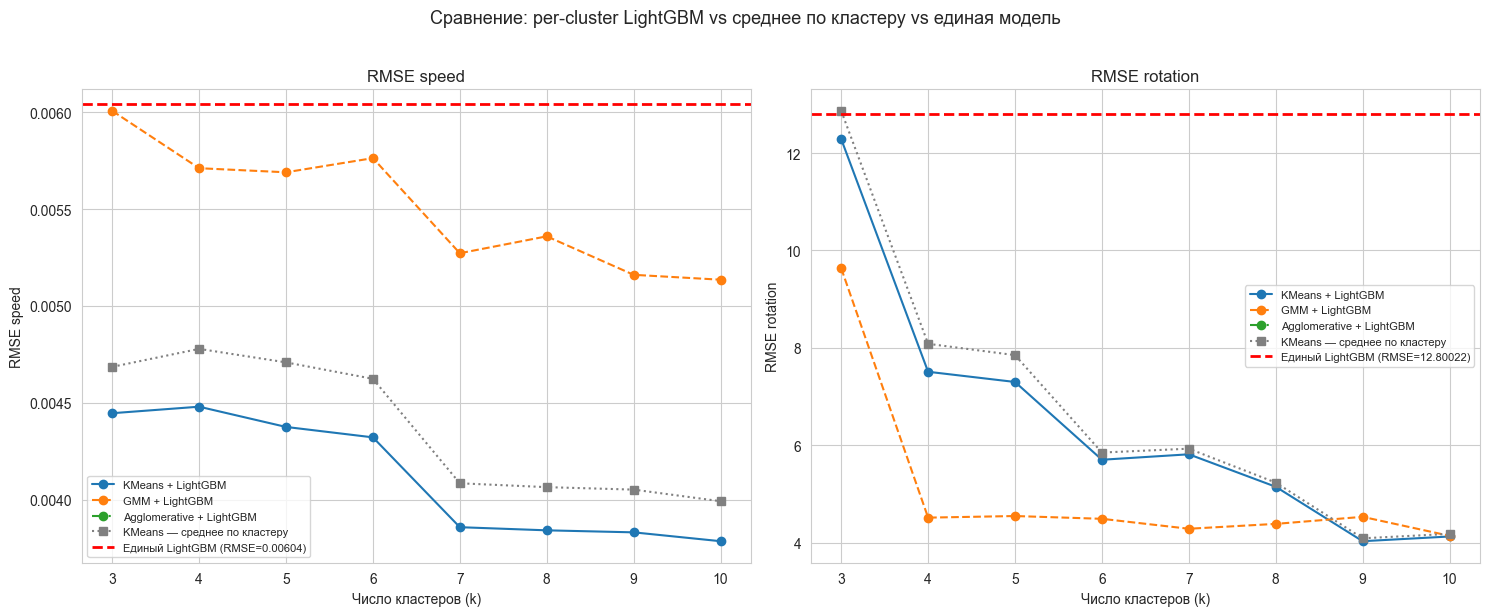

Зазор между серой и цветной линией = выигрыш от регрессии внутри режима
Зазор между красной и цветной линией = выигрыш от кластеризации


In [ ]:
# ── Сводный график: 3 линии на одном графике ──
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, target in zip(axes, TARGETS):
    col = f'rmse_{target}'
    
    for method, ls in [('KMeans', '-'), ('GMM', '--'), ('Agglomerative', '-.')]:
        sub = results_df[results_df['method'] == method].sort_values('k')
        ax.plot(sub['k'], sub[col], f'o{ls}', label=f'{method} + LightGBM', markersize=6)
    
    bm_km = baseline_mean_df[baseline_mean_df['method'] == 'KMeans'].sort_values('k')
    ax.plot(bm_km['k'], bm_km[col], 's:', color='gray', label='KMeans — среднее по кластеру', markersize=6)
    
    ax.axhline(baseline_single[col], color='red', ls='--', lw=2, label=f'Единый LightGBM (RMSE={baseline_single[col]:.5f})')
    
    ax.set_xlabel('Число кластеров (k)')
    ax.set_ylabel(f'RMSE {target}')
    ax.set_title(f'RMSE {target}')
    ax.legend(fontsize=8)
    ax.set_xticks(list(k_range))

plt.suptitle('Сравнение: per-cluster LightGBM vs среднее по кластеру vs единая модель', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Зазор между серой и цветной линией = выигрыш от регрессии внутри режима')
print('Зазор между красной и цветной линией = выигрыш от кластеризации')

In [20]:
# ── Числовая сводка ──
print('=' * 75)
print(f'Лучшая конфигурация: {BEST_METHOD} k={BEST_K} + per-cluster LightGBM')
print('=' * 75)
for target in TARGETS:
    col = f'rmse_{target}'
    rmse_model = best_eval[col]
    rmse_mean = baseline_mean_df[
        (baseline_mean_df['method'] == BEST_METHOD) & 
        (baseline_mean_df['k'] == BEST_K)
    ][col].values[0]
    rmse_single = baseline_single[col]
    
    print(f'\n  {target}:')
    print(f'    Среднее по кластеру (бейзлайн 1):  RMSE = {rmse_mean:.6f}')
    print(f'    Per-cluster LightGBM:               RMSE = {rmse_model:.6f}  '
          f'(↓{(1 - rmse_model/rmse_mean)*100:.1f}% vs среднее)')
    print(f'    Единый LightGBM (бейзлайн 2):      RMSE = {rmse_single:.6f}  '
          f'(разница: {(1 - rmse_model/rmse_single)*100:+.1f}% vs per-cluster)')

print('\n' + '=' * 75)
print('Интерпретация:')
print('  Большой зазор бейзлайн1 → модель: давления информативны внутри режима')
print('  Большой зазор бейзлайн2 → модель: кластеризация реально помогает')
print('  Маленькие зазоры: возможно, кластеры уже всё объяснили средним,')  
print('  или кластеризация не даёт выигрыша над единой моделью')

Лучшая конфигурация: KMeans k=9 + per-cluster LightGBM

  speed:
    Среднее по кластеру (бейзлайн 1):  RMSE = 0.004051
    Per-cluster LightGBM:               RMSE = 0.003831  (↓5.4% vs среднее)
    Единый LightGBM (бейзлайн 2):      RMSE = 0.006045  (разница: +36.6% vs per-cluster)

  rotation:
    Среднее по кластеру (бейзлайн 1):  RMSE = 4.087548
    Per-cluster LightGBM:               RMSE = 4.028043  (↓1.5% vs среднее)
    Единый LightGBM (бейзлайн 2):      RMSE = 12.800224  (разница: +68.5% vs per-cluster)

Интерпретация:
  Большой зазор бейзлайн1 → модель: давления информативны внутри режима
  Большой зазор бейзлайн2 → модель: кластеризация реально помогает
  Маленькие зазоры: возможно, кластеры уже всё объяснили средним,
  или кластеризация не даёт выигрыша над единой моделью


## 10. Раздельная проверка: speed и rotation могут требовать разного k

Энергоёмкость может не быть единственным скрытым параметром. Если оптимальный k для speed ≠ k для rotation — это сигнал.

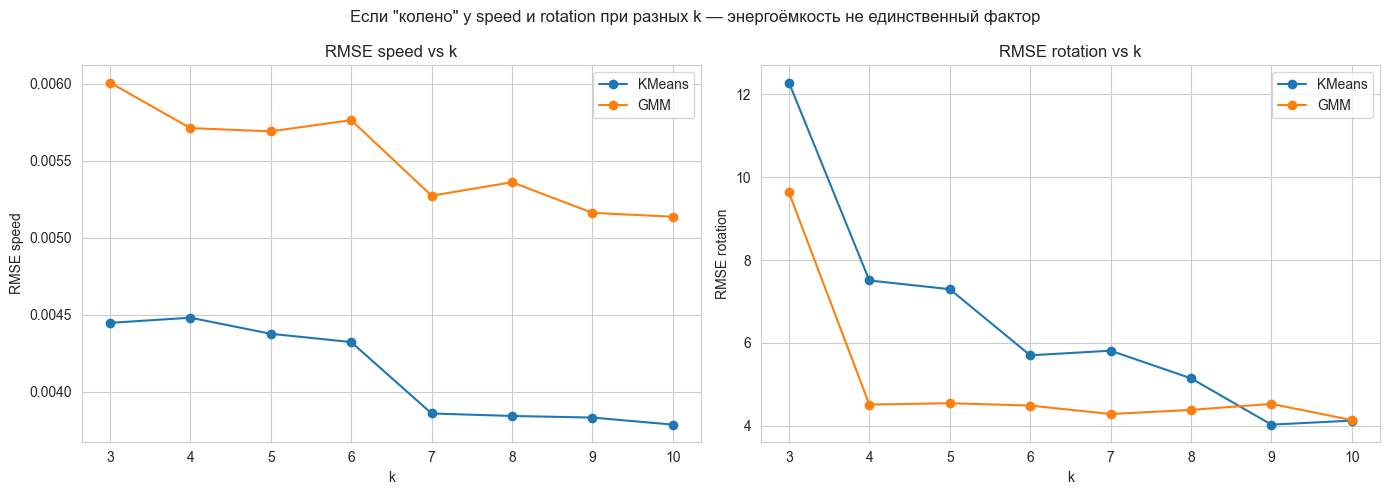

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, target in zip(axes, TARGETS):
    for method in ['KMeans', 'GMM']:
        sub = results_df[results_df['method'] == method].sort_values('k')
        ax.plot(sub['k'], sub[f'rmse_{target}'], 'o-', label=method)
    ax.set_xlabel('k')
    ax.set_ylabel(f'RMSE {target}')
    ax.set_title(f'RMSE {target} vs k')
    ax.legend()
    ax.set_xticks(list(k_range))

plt.suptitle('Если "колено" у speed и rotation при разных k — энергоёмкость не единственный фактор', fontsize=12)
plt.tight_layout()
plt.show()

## 11. Итоговая сводка

In [22]:
print('=' * 70)
print('ИТОГОВАЯ СВОДКА')
print('=' * 70)
print(f'Метод кластеризации:  {BEST_METHOD}')
print(f'Число кластеров (k):  {BEST_K}')
print(f'Регрессор:            LightGBM (per-cluster)')
print(f'Валидация:            GroupKFold по well_id, {N_SPLITS} фолдов')
print('-' * 70)
print(f'RMSE speed:           {best_eval["rmse_speed"]:.6f}')
print(f'RMSE rotation:        {best_eval["rmse_rotation"]:.4f}')
print(f'R² speed:             {best_eval["r2_speed"]:.4f}')
print(f'R² rotation:          {best_eval["r2_rotation"]:.4f}')
print('-' * 70)
print('Per-cluster:')
for _, r in pc.iterrows():
    print(f'  Кластер {int(r["cluster"])}: n={int(r["n_obs"]):>6d}  '
          f'RMSE_speed={r["rmse_speed"]:.6f}  RMSE_rot={r["rmse_rotation"]:.4f}')
print('=' * 70)

ИТОГОВАЯ СВОДКА
Метод кластеризации:  KMeans
Число кластеров (k):  9
Регрессор:            LightGBM (per-cluster)
Валидация:            GroupKFold по well_id, 5 фолдов
----------------------------------------------------------------------
RMSE speed:           0.003831
RMSE rotation:        4.0280
R² speed:             0.6647
R² rotation:          0.9092
----------------------------------------------------------------------
Per-cluster:
  Кластер 0: n=104426  RMSE_speed=0.002748  RMSE_rot=2.5221
  Кластер 1: n= 38364  RMSE_speed=0.003606  RMSE_rot=4.5813
  Кластер 2: n= 88693  RMSE_speed=0.002951  RMSE_rot=2.9238
  Кластер 3: n= 30015  RMSE_speed=0.005038  RMSE_rot=6.2164
  Кластер 4: n= 15713  RMSE_speed=0.006235  RMSE_rot=10.2183
  Кластер 5: n= 27418  RMSE_speed=0.005435  RMSE_rot=0.6182
  Кластер 6: n= 17606  RMSE_speed=0.004178  RMSE_rot=7.9354
  Кластер 7: n= 83775  RMSE_speed=0.003877  RMSE_rot=2.6356
  Кластер 8: n=  9039  RMSE_speed=0.005585  RMSE_rot=0.7381
